# ImageNet Classification for the MLA100 NPU chip


## Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.txt imagenet_train20.txt
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.txt imagenet_val20.txt

# Text contains:
# file class_number
# file2 class_number2
# ...

In [3]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_train20.zip imagenet_train20.zip

In [4]:
!unzip -q imagenet_train20.zip
#   inflating: imagenet_train20a/n04346328/n04346328_2302.JPEG
#  inflating: imagenet_train20a/n04346328/n04346328_2842.JPEG

In [5]:
!cp /content/drive/MyDrive/NPULab/spring-2026-data/imagenet_val20.zip imagenet_val20.zip

In [6]:
!unzip -q imagenet_val20.zip

## Install Requirements

In [7]:
!pip -q install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 13.8 MB/s eta 0:00:00


In [8]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.onnx
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import onnxscript

## Prepare Dataset Loader

In [9]:
IMAGE_ROOT = 'imagenet_train20a'
TRAIN_LIST = 'imagenet_train20.txt'
VAL_IMAGE_ROOT = 'imagenet_val20'
VAL_LIST = 'imagenet_val20.txt'
BATCH_SIZE = 32
NUM_CLASSES = 20
INPUT_SHAPE = (240, 240)
NUM_EPOCHS = 10
LEARNING_RATE = 0.01

In [10]:
class ImageNet20Dataset(Dataset):
    def __init__(self, txt_file, root_dir, transform=None):
        self.img_labels = []
        self.root_dir = root_dir
        self.transform = transform
        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    self.img_labels.append((parts[0], int(parts[1])))

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        filename, label = self.img_labels[idx]

        path_flat = os.path.join(self.root_dir, filename)
        path_nested = os.path.join(self.root_dir, filename.split('_')[0], filename)
        full_path = path_flat if os.path.exists(path_flat) else path_nested

        try:
            image = Image.open(full_path).convert("RGB")
        except Exception:
            image = Image.new('RGB', (240, 240)) # Fallback if both fail

        if self.transform: image = self.transform(image)
        return image, label



In [36]:
class ReflectiveRotation:
    def __init__(self, degrees, size):
        self.degrees = degrees
        self.size = size

    def __call__(self, img):
        angle = transforms.RandomRotation.get_params([-self.degrees, self.degrees])
        pad_size = int(max(img.size) * 0.5)
        img = transforms.functional.pad(img, pad_size, padding_mode='reflect')
        img = transforms.functional.rotate(img, angle)
        img = transforms.functional.center_crop(img, self.size)
        return img

# alter the training dataset for training
train_transform = transforms.Compose([
    ReflectiveRotation(degrees=25, size=INPUT_SHAPE),
    transforms.RandomResizedCrop(INPUT_SHAPE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
])

# keep validation unaltered
transform_val = transforms.Compose([
    transforms.Resize(INPUT_SHAPE),
    transforms.ToTensor(),
])

train_dataset = ImageNet20Dataset(txt_file=TRAIN_LIST, root_dir=IMAGE_ROOT, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Dataset loaded: {len(train_dataset)} images found.")


val_dataset = ImageNet20Dataset(txt_file=VAL_LIST, root_dir=VAL_IMAGE_ROOT, transform=transform_val)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Dataset loaded: {len(val_dataset)} images found.")

Dataset loaded: 6000 images found.
Dataset loaded: 1000 images found.


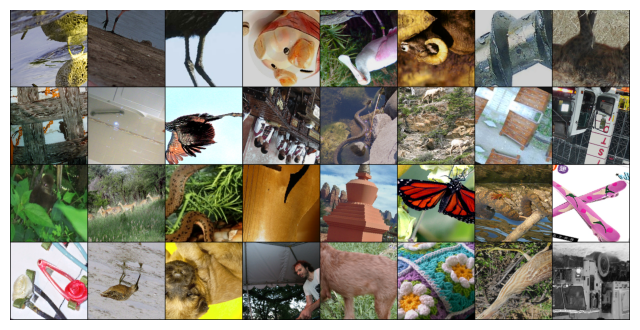

In [43]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

dataiter = iter(train_loader)
images, labels = next(dataiter)

images_to_show = images[:64]

grid_img = torchvision.utils.make_grid(images_to_show, nrow=8, padding=2)

np_img = grid_img.numpy()
formatted_img = np.transpose(np_img, (1, 2, 0))

plt.figure(figsize=(8, 8))
plt.imshow(formatted_img)
plt.axis('off')
plt.show()

# Single Cutmix

In [57]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch

def rand_bbox(size, lam):
    """Generates a dynamic, randomized bounding box based on a lambda value."""
    W = size[2] # Image Width
    H = size[3] # Image Height

    # Calculate the dimensions of the cut based on lambda
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    # Choose a completely random center for the box
    cx = np.random.randint(W)
    cy = np.random.randint(H)

    # Calculate the coordinates of the bounding box, ensuring they stay within image bounds
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

import numpy as np
import torch
import matplotlib.pyplot as plt

def apply_mixup(images, labels, alpha=1.0):
    batch_size = images.size(0)
    lam_val = np.random.beta(alpha, alpha)

    rand_index = torch.randperm(batch_size)
    target_a = labels
    target_b = labels[rand_index]

    mixed_images = lam_val * images + (1 - lam_val) * images[rand_index, :]

    # Formalize: return lam as a tensor for the whole batch
    lam = torch.full((batch_size,), lam_val, dtype=torch.float32)

    return mixed_images, target_a, target_b, lam

def apply_hmix(images, labels, alpha=1.0, r=0.5):
    """
    True HMix: Hybrid version of Mixup and CutMix as defined by Park et al.
    Combines a shrunken CutMix patch with Mixup blending outside the patch.
    """
    batch_size = images.size(0)
    H, W = images.size(2), images.size(3)

    # 1. Sample lambda for each image in the batch
    lam_array = np.random.beta(alpha, alpha, size=batch_size)

    # 2. Shuffle targets
    rand_index = torch.randperm(batch_size)
    target_a = labels
    target_b = labels[rand_index]

    # 3. Calculate the Mixup ratio for the areas OUTSIDE the box.
    # Formula from paper: lambda / (1 - (1 - lambda) * r)
    mixup_lams = lam_array / (1.0 - (1.0 - lam_array) * r)

    # Reshape to (Batch, Channel, Height, Width) for tensor broadcasting
    mix_tensor = torch.tensor(mixup_lams, dtype=torch.float32).view(-1, 1, 1, 1)

    # Apply standard Mixup to the ENTIRE image first
    mixed_images = mix_tensor * images + (1.0 - mix_tensor) * images[rand_index, :]

    # 4. Calculate CutMix box dimensions (shrunk by factor of sqrt(r))
    cut_rats = np.sqrt(1. - lam_array) * np.sqrt(r)
    cut_w = (W * cut_rats).astype(int)
    cut_h = (H * cut_rats).astype(int)

    # 5. Generate random box centers
    cx = np.random.randint(0, W, size=batch_size)
    cy = np.random.randint(0, H, size=batch_size)

    # Snap boxes to boundaries
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    # 6. Apply CutMix INSIDE the box (Overwriting the mixup background)
    for i in range(batch_size):
        x1, y1, x2, y2 = bbx1[i], bby1[i], bbx2[i], bby2[i]

        # Inside the box, the mask component is 0 (meaning 100% Image B)
        mixed_images[i, :, y1:y2, x1:x2] = images[rand_index[i], :, y1:y2, x1:x2]

    # Because of the mathematical scaling of the background mixup,
    # the overall expected value of the label remains exactly lam_array.
    lam = torch.tensor(lam_array, dtype=torch.float32)

    return mixed_images, target_a, target_b, lam

def apply_instance_cutmix(images, labels, alpha=1.0):
    batch_size = images.size(0)
    W = images.size(3)
    H = images.size(2)

    lam_array = np.random.beta(alpha, alpha, size=batch_size)

    rand_index = torch.randperm(batch_size)
    target_a = labels
    target_b = labels[rand_index]

    cut_rats = np.sqrt(1. - lam_array)
    cut_w = (W * cut_rats).astype(int)
    cut_h = (H * cut_rats).astype(int)

    cx = np.random.randint(0, W, size=batch_size)
    cy = np.random.randint(0, H, size=batch_size)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    mixed_images = images.clone()
    actual_lam = np.zeros(batch_size, dtype=np.float32)

    for i in range(batch_size):
        x1, y1, x2, y2 = bbx1[i], bby1[i], bbx2[i], bby2[i]
        mixed_images[i, :, y1:y2, x1:x2] = images[rand_index[i], :, y1:y2, x1:x2]
        actual_lam[i] = 1.0 - ((x2 - x1) * (y2 - y1) / (W * H))

    # Formalize: already calculated per instance
    lam = torch.tensor(actual_lam, dtype=torch.float32)

    return mixed_images, target_a, target_b, lam

import numpy as np
import torch

def generate_fmix_mask(lam, size, decay_power=3.0):
    """
    Generates a continuous, low-frequency 2D mask using inverse FFT.
    """
    H, W = size

    # 1. Generate grid of frequencies
    freqs_x = np.fft.fftfreq(W)
    freqs_y = np.fft.fftfreq(H)
    fx, fy = np.meshgrid(freqs_x, freqs_y)

    # 2. Calculate distance from origin (low frequencies are near 0)
    freq_sq = fx**2 + fy**2
    freq_sq[0, 0] = 1.0 # Prevent division by zero at the DC component

    # 3. Apply the decay to filter out high frequencies
    amp = 1.0 / (freq_sq ** (decay_power / 2.0))
    amp[0, 0] = 0.0 # Remove DC component

    # 4. Give it random phase to randomize the shape
    phase = np.random.uniform(0, 2 * np.pi, (H, W))
    complex_spec = amp * np.exp(1j * phase)

    # 5. Inverse FFT to get it back into the spatial (pixel) domain
    img = np.fft.ifft2(complex_spec).real

    # 6. Threshold the continuous image to get a binary mask of exact size lambda
    img_flat = img.flatten()

    # We want (1 - lam) proportion to be 0s, and lam proportion to be 1s
    idx = int((1.0 - lam) * len(img_flat))
    idx = min(max(idx, 0), len(img_flat) - 1)

    threshold = np.sort(img_flat)[idx]
    binary_mask = (img > threshold).astype(np.float32)

    return binary_mask

def apply_fmix(images, labels, alpha=1.0, decay_power=3.0):
    """
    Applies FMix augmentation across the batch.
    """
    batch_size = images.size(0)
    H, W = images.size(2), images.size(3)

    # 1. Sample lambdas
    lam_array = np.random.beta(alpha, alpha, size=batch_size)

    # 2. Shuffle targets
    rand_index = torch.randperm(batch_size)
    target_a = labels
    target_b = labels[rand_index]

    mixed_images = images.clone()
    actual_lam = np.zeros(batch_size, dtype=np.float32)

    # 3. Apply unique organic masks to each image
    for i in range(batch_size):
        lam_target = lam_array[i]

        # Generate the amoeba mask
        mask = generate_fmix_mask(lam_target, (H, W), decay_power)

        # Calculate the actual lambda (in case of tiny rounding errors)
        actual_lam[i] = mask.sum() / (H * W)

        # Convert to tensor and broadcast over channels (C, H, W)
        mask_tensor = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        # Mix the images
        mixed_images[i] = mask_tensor * images[i] + (1.0 - mask_tensor) * images[rand_index[i]]

    actual_lam = torch.tensor(actual_lam, dtype=torch.float32)

    return mixed_images, target_a, target_b, actual_lam

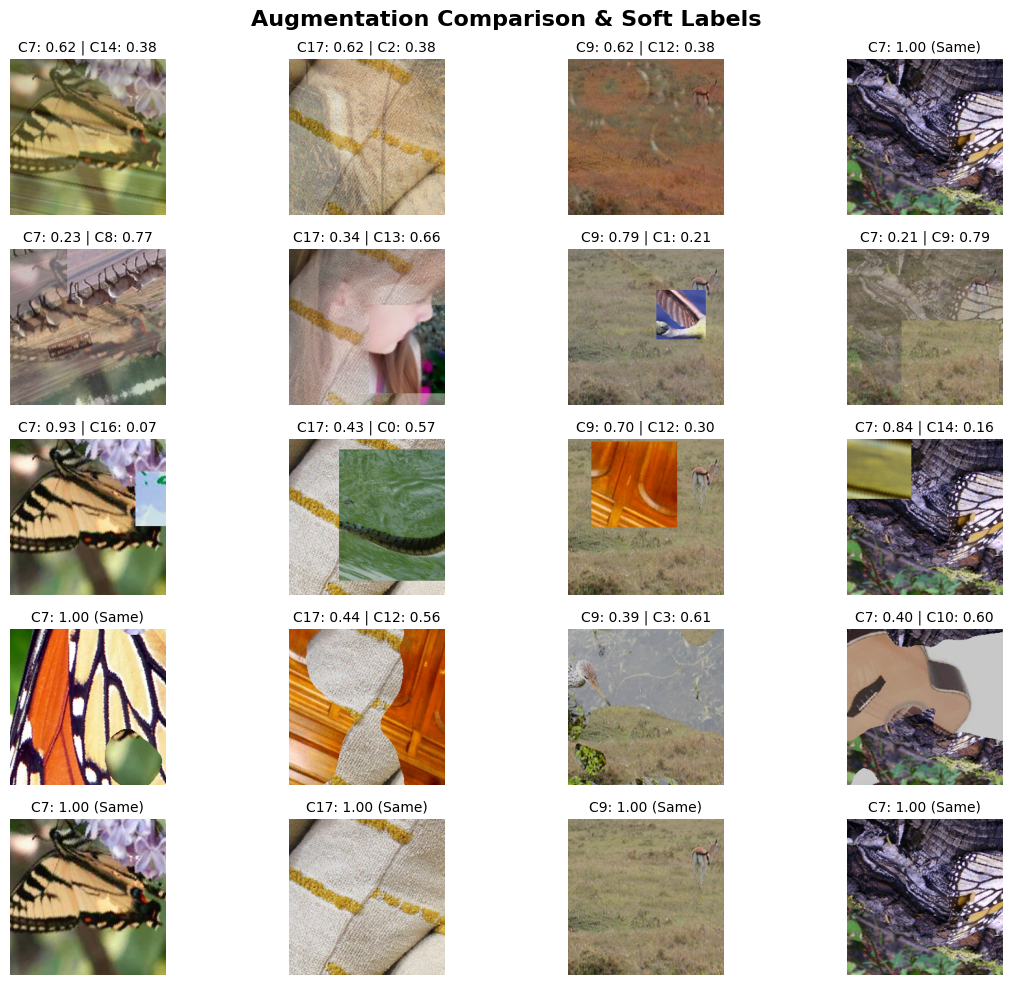

In [60]:
# 1. Grab a single batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 2. Apply all three methods (properly unpacking all 4 returned values)
mixup_imgs, mixup_ta, mixup_tb, mixup_lam = apply_mixup(images, labels)
hmix_imgs, hmix_ta, hmix_tb, hmix_lam = apply_hmix(images, labels)
cutmix_imgs, cutmix_ta, cutmix_tb, cutmix_lam = apply_instance_cutmix(images, labels)
fmix_imgs, fmix_ta, fmix_tb, fmix_lam = apply_fmix(images, labels)

# 3. Setup the plot configuration
configs = [
    ("Mixup", mixup_imgs, mixup_ta, mixup_tb, mixup_lam),
    ("H-Mix", hmix_imgs, hmix_ta, hmix_tb, hmix_lam),
    ("CutMix", cutmix_imgs, cutmix_ta, cutmix_tb, cutmix_lam),
    ("FMix", fmix_imgs, fmix_ta, fmix_tb, fmix_lam),
    ("Reality", images, labels, labels, labels)
]

num_cols = 4
fig, axes = plt.subplots(len(configs), num_cols, figsize=(12, 10))

# 4. Loop through configurations to build a comparative grid
for row_idx, (name, mix_imgs, ta, tb, lam) in enumerate(configs):
    for col_idx in range(num_cols):
        ax = axes[row_idx, col_idx]

        # Format for Matplotlib
        img = mix_imgs[col_idx].numpy()
        img = np.transpose(img, (1, 2, 0))
        img = np.clip(img, 0, 1)

        class_a = ta[col_idx].item()
        class_b = tb[col_idx].item()
        lam_i = lam[col_idx].item()

        ax.imshow(img)
        ax.axis('off')

        if col_idx == 0:
            ax.set_ylabel(name, fontsize=14, fontweight='bold', visible=True)
            # Hack to make ylabel visible without axis lines
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_yticks([])
            ax.set_xticks([])

        title_text = f"C{class_a}: {lam_i:.2f} | C{class_b}: {1 - lam_i:.2f}"
        if class_a == class_b:
            title_text = f"C{class_a}: 1.00 (Same)"

        ax.set_title(title_text, fontsize=10)

plt.suptitle("Augmentation Comparison & Soft Labels", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()